# Train Tabular Q-Learning

Install the notebook dependencies from the repository root with `python -m pip install -e ".[notebook]"`.

In [11]:
import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np

from aprenderl import QLearning, QLearningConfig
from aprenderl.utils import evaluate_policy

ENV_ID = "Taxi-v4"

In [12]:
env = gym.make(ENV_ID)
config = QLearningConfig(
    learning_rate=0.2,
    gamma=0.95,
    exploration_steps=80_000,
)

agent = QLearning(env, config=config)
agent.learn(total_timesteps=100_000)
env.close()

QLearning: 100%|██████████| 100000/100000 [00:09<00:00, 10485.50step/s, episodes=2835, updates=1e+5, return=5.0, epsilon=0.050, td_error=0.000]   


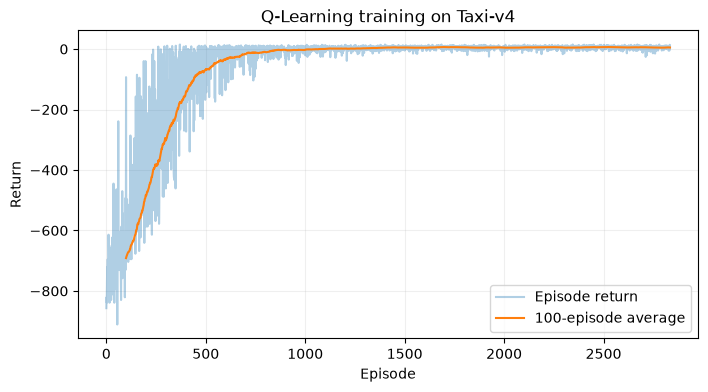

In [13]:
returns = np.asarray(agent.episode_returns)
window = min(100, len(returns))
moving_average = np.convolve(returns, np.ones(window) / window, mode="valid")

plt.figure(figsize=(8, 4))
plt.plot(returns, alpha=0.35, label="Episode return")
plt.plot(
    np.arange(window - 1, len(returns)),
    moving_average,
    label=f"{window}-episode average",
)
plt.xlabel("Episode")
plt.ylabel("Return")
plt.title(f"Q-Learning training on {ENV_ID}")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

## Watch the trained policy

This opens a window and runs 5 episodes using deterministic actions. Each Taxi episode starts with a new taxi, passenger, and destination configuration.

In [14]:
evaluation_env = gym.make(ENV_ID, render_mode="human")
try:
    result = evaluate_policy(agent, evaluation_env, episodes=5)
finally:
    evaluation_env.close()

print("Episode returns:", result.returns)
print(f"Mean return: {result.mean_return:.1f} +/- {result.return_std:.1f}")

Episode returns: (4.0, 7.0, 7.0, 10.0, 9.0)
Mean return: 7.4 +/- 2.1
